# Ejecución y Validación del IAI

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os

#importamos motor logico del IAI
module_path = os.path.abspath(os.path.join('..')) 

if module_path not in sys.path:
    sys.path.append(module_path)
from src.IAI_estimador import calculate_iai


In [2]:
OUTPUT_DIR = "resultados_IAI"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path,dpi=300, bbox_inches="tight")
    print(f"  [guardado] {path}")
   

In [3]:
#Cargamos el Dataaset historico limpio
df_hist_clean = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_clean.parquet")

# Calcular Índice de Idoneidad Agroclimática (IAI)

In [4]:
# Aplicamos la función vectorizada 
df_iai_hist = calculate_iai(df_hist_clean)

# Extraemos los valores para graficar
iai_values = df_iai_hist["IAI"].to_numpy()

print(f" IAI calculado exitosamente para {len(iai_values):,} parcelas.")

 IAI calculado exitosamente para 633,952 parcelas.


  [guardado] resultados_IAI\hist_distribucion_iai.png


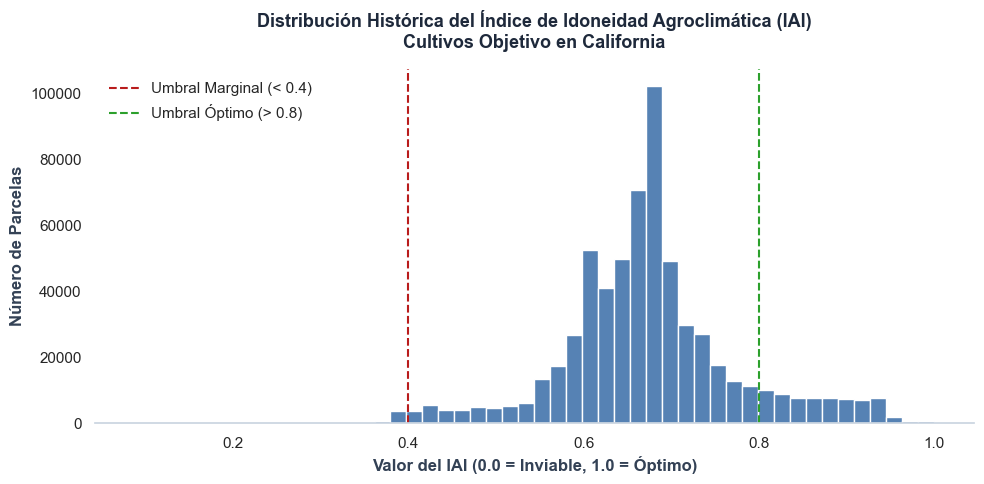

statistic,IAI
str,f64
"""count""",633952.0
"""null_count""",0.0
"""mean""",0.674043
"""std""",0.099807
"""min""",0.087681
"""25%""",0.619097
"""50%""",0.672222
"""75%""",0.713333
"""max""",1.0


In [5]:
# HISTOGRAMA DE VALIDACIÓN

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma con la paleta institucional
sns.histplot(iai_values, bins=50, color="#4374ac", edgecolor="white", alpha=0.9, ax=ax)

# Líneas de corte analítico
ax.axvline(0.4, color='#b91c1c', linestyle='--', linewidth=1.5, label='Umbral Marginal (< 0.4)')
ax.axvline(0.8, color='#2ca02c', linestyle='--', linewidth=1.5, label='Umbral Óptimo (> 0.8)')

# Estética
ax.set_title("Distribución Histórica del Índice de Idoneidad Agroclimática (IAI)\nCultivos Objetivo en California", 
             fontsize=13, fontweight="bold", pad=15, color="#1e293b")
ax.set_xlabel("Valor del IAI (0.0 = Inviable, 1.0 = Óptimo)", fontweight="bold", color="#334155")
ax.set_ylabel("Número de Parcelas", fontweight="bold", color="#334155")

ax.grid(False)
sns.despine(left=True, bottom=False)
ax.spines['bottom'].set_color('#cbd5e1')
ax.legend(frameon=False)

plt.tight_layout()
save(fig, "hist_distribucion_iai.png")
plt.show()

# Resumen estadístico
display(df_iai_hist.select("IAI").describe())

In [6]:
# Componendes del IAI
pl.Config.set_tbl_rows(30)
# Calculamos la media de cada componente individual para toda California
componentes = df_iai_hist.select(["I_GDD", "I_temp", "I_precip", "I_suelo"]).mean()
display(componentes)

# Y para ver si el problema es general o de un cultivo en específico:
print("\n PROMEDIO DEL ÍNDICE DE TEMPERATURA POR CULTIVO:")
display(df_iai_hist.group_by("crop_name").agg(pl.col("I_temp").mean()).sort("I_temp"))

I_GDD,I_temp,I_precip,I_suelo
f64,f64,f64,f64
0.989154,0.913091,0.127617,0.585597



 PROMEDIO DEL ÍNDICE DE TEMPERATURA POR CULTIVO:


crop_name,I_temp
str,f64
"""Lettuce""",0.113423
"""Wheat""",0.5079
"""Alfalfa""",0.906791
"""Pistachios""",0.980764
"""Strawberries""",0.994365
"""Oranges""",0.99748
"""Grapes""",0.997962
"""Tomatoes""",0.998851
"""Cotton""",0.999222


In [7]:
df_iai_hist.write_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai.parquet")